# Contextual Compression Index

**1. 검색 속도 및 인덱싱 효율성 향상**

* 청크 수의 감소: 원문을 잘게 쪼개어 수만 개의 청크로 만드는 대신, 문서당 하나의 요약문만 인덱싱한다면 전체 벡터의 개수($N$)가 줄어든다. 결과적으로 전체 인덱스 용량($N \times d$)이 줄어들어 메모리를 절약하게 된다.

* **메모리(RAM) 절약:** 인덱스 크기가 작아지므로 동일한 메모리 사양에서 더 많은 문서를 관리하거나, 더 저렴한 인프라 비용으로 시스템을 운영할 수 있다.

**2. 검색 노이즈 제거 (Denoising)**

* **의미적 응집도 강화:** 문서에는 질문과 상관없는 부차적인 설명이나 수식어구가 포함되어 있다. 인덱싱 단계에서 이를 제거하고 핵심 의미(Semantic core)만 남겨 저장하면, 검색 시 질문 벡터와 문서 벡터 간의 정합성이 높아져 검색 정확도가 향상된다.
* **장문 문서 처리:** 아주 긴 문서는 임베딩 모델의 토큰 제한에 걸려 정보가 소실될 수 있다. 이를 미리 요약하여 압축 인덱스에 넣으면 문서 전체의 맥락을 검색 단계에서 더 잘 반영할 수 있다.

**3. 'Multi-Vector' 전략의 활용**

* **요약문 기반 검색, 원문 기반 답변:** 압축 인덱스(`ir-compressed`)에서 질문과 가장 관련 있는 요약본을 빠르게 찾아낸 뒤, 실제 LLM에게 전달할 때는 해당 요약본과 연결된(Parent-Child 관계) 원문(`ir`)을 불러오는 구조를 취할 수 있다.
* 이를 통해 **"검색은 가볍고 정확하게, 답변은 풍부한 맥락으로"** 수행하는 하이브리드 접근이 가능하다.

**4. 검색 품질의 일관성 유지**

* 다양한 포맷(PDF, HTML, 로그 파일 등)의 데이터를 표준화된 요약 형태로 인덱싱하면, 데이터 소스의 형태에 구애받지 않고 일관된 검색 성능을 기대할 수 있다.

**요약 및 비교**

| 항목 | 원문 인덱스 검색 | 압축 인덱스 검색 (ir-compressed) |
| --- | --- | --- |
| **검색 대상** | 문서 청크 전체 | 요약문, 키워드, 혹은 핵심 추출문 |
| **주요 장점** | 정보 손실 없음 | 검색 속도 빠름, 노이즈 적음 |
| **데이터 구조** | 단순 저장 | Parent-Child 또는 요약-원문 매핑 필요 |

이러한 방식은 특히 **데이터 양이 방대하여 검색 비용이 부담되거나, 문서 하나하나의 길이가 길어 검색 정확도가 떨어질 때** 매우 유용하다.

In [1]:
%pip install -Uq python-dotenv langchain langchain-openai langchain-pinecone

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from dotenv import load_dotenv
import os

load_dotenv()
os.environ['LANGSMITH_TRACING'] = 'true'
os.environ['LANGSMITH_ENDPOINT'] = 'https://api.smith.langchain.com'
os.environ['LANGSMITH_API_KEY'] = os.getenv('langsmith_key')
os.environ['LANGSMITH_PROJECT'] = 'skn23-langchain'
os.environ['OPENAI_API_KEY'] = os.getenv("openai_key")
os.environ['PINECONE_API_KEY'] = os.getenv("pinecone_key")
os.environ['COHERE_API_KEY'] = os.getenv('cohere_key')

## 데이터 준비

In [ ]:
import pandas as pd

documents_df = pd.read_csv('documents.csv')
queries_df = pd.read_csv('queries.csv')

## 문서요약 체인 & 문서 압축

In [4]:
from langchain.chat_models import init_chat_model
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from tqdm.auto import tqdm
import time

llm = init_chat_model('gpt-4.1-mini', temperature=0.3)
prompt = PromptTemplate.from_template('''
당신은 정보의 본질을 빠르고 정확하게 파악해내는 **요약전문가**입니다.
다음 지문에서 핵심내용만을 효과적으로, 효율적으로 요약하세요.

{text}
''')
output_parser = StrOutputParser()
summary_chain = prompt | llm | output_parser

compressed_texts = []
for idx, row in tqdm(documents_df.iterrows(), desc='문서요약/압축', ncols=70):
    doc_id = row['doc_id']
    content = row['content']
    summary = summary_chain.invoke({'text': content})
    compressed_texts.append({'doc_id': doc_id, 'content': summary})
    time.sleep(.5)

compressed_df = pd.DataFrame(compressed_texts)
compressed_df

c:\Users\user\nlp\natural_language_processing\nlp_venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
문서요약/압축: 30it [00:48,  1.61s/it]


,doc_id,content
0,D1,"제주도는 한라산 등반, 성산 일출봉 관광, 해변 활동 등 다양한 관광 명소와 활동을..."
1,D2,"비빔밥은 조선 시대부터 전해 내려온 한국의 대표 음식으로, 밥 위에 채소와 고기 등..."
2,D3,"걸스데이는 2010년 데뷔한 대한민국 4인조 걸그룹으로, 대표곡은 “Somethin..."
3,D4,"세종대왕(1397~1450)은 조선의 4대 임금으로, 훈민정음을 창제하여 한글을 보..."
4,D5,이순신 장군(1545~1598)은 임진왜란 중 명량 해전에서 13척의 배로 133척...
5,D6,"2024년 전 지구 평균 기온은 산업화 이전 대비 약 1.2℃ 상승했고, 해수면도 ..."
6,D7,"최근 인공지능 분야에서는 생성형 AI, 멀티모달 모델, 강화학습 기반 에이전트 개발..."
7,D8,"서울 지하철은 1호선부터 9호선까지 운행되며, 주요 환승역으로 서울역, 강남역, 종..."
8,D9,"판소리는 소리꾼과 고수가 함께 공연하는 한국 전통 음악으로, 대표 작품으로는 “춘향..."
9,D10,한국 축구 대표팀은 2002 한일 월드컵 4강 진출과 2012 런던 올림픽 동메달 ...


In [5]:
pd.set_option('display.max_colwidth', None)
pd.merge(documents_df[['doc_id', 'content']], compressed_df, on='doc_id', suffixes=('', '_copressed'))

,doc_id,content,content_copressed
0,D1,"제주도는 대한민국의 대표 관광지로서, 한라산 등반, 성산 일출봉 관광, 해변 활동(...","제주도는 한라산 등반, 성산 일출봉 관광, 해변 활동 등 다양한 관광 명소와 활동을 갖춘 대한민국 대표 관광지이다."
1,D2,"비빔밥은 조선 시대부터 전해 내려온 대표적 한국 음식으로, 밥 위에 고명(채소·고기...","비빔밥은 조선 시대부터 전해 내려온 한국의 대표 음식으로, 밥 위에 채소와 고기 등 다양한 고명을 올려 비벼 먹는 요리이다."
2,D3,"걸스데이는 2010년 데뷔한 대한민국의 4인조 걸그룹으로, 대표곡으로는 “Somet...","걸스데이는 2010년 데뷔한 대한민국 4인조 걸그룹으로, 대표곡은 “Something” 등이다."
3,D4,세종대왕(1397~1450)은 훈민정음을 창제하여 한글을 보급한 조선의 4대 임금입...,"세종대왕(1397~1450)은 조선의 4대 임금으로, 훈민정음을 창제하여 한글을 보급한 위대한 군주이다."
4,D5,이순신 장군(1545~1598)은 임진왜란 당시 명량 해전에서 13척의 배로 133...,이순신 장군(1545~1598)은 임진왜란 중 명량 해전에서 13척의 배로 133척의 일본 함대를 격파한 위대한 해군 지휘관이다.
5,D6,"2024년 전 지구 평균 기온은 산업화 이전 대비 약 1.2℃ 상승했으며, 해수면 ...","2024년 전 지구 평균 기온은 산업화 이전 대비 약 1.2℃ 상승했고, 해수면도 함께 상승했다."
6,D7,"최근 인공지능 분야에서는 생성형 AI, 멀티모달 모델, 강화학습 기반 에이전트 개발...","최근 인공지능 분야에서는 생성형 AI, 멀티모달 모델, 강화학습 기반 에이전트 개발이 활발히 진행되고 있다."
7,D8,"서울 지하철은 1호선부터 9호선까지 운행되며, 주요 환승역으로는 서울역·강남역·종로...","서울 지하철은 1호선부터 9호선까지 운행되며, 주요 환승역으로 서울역, 강남역, 종로역 등이 있다."
8,D9,"판소리는 소리꾼과 고수가 함께 공연하는 한국 전통 음악으로, 대표 작품에는 “춘향가...","판소리는 소리꾼과 고수가 함께 공연하는 한국 전통 음악으로, 대표 작품으로는 “춘향가” 등이 있다."
9,D10,"한국 축구 대표팀은 2002 한일 월드컵 4강 진출, 2012 런던 올림픽 동메달 ...",한국 축구 대표팀은 2002 한일 월드컵 4강 진출과 2012 런던 올림픽 동메달 획득 등 주요 국제 대회에서 뛰어난 성과를 거두었다.


## Pinecone Index 생성

In [ ]:
# pc.delete_index('ir-compressed')

In [7]:
from pinecone import Pinecone, ServerlessSpec

pc = Pinecone() # pinecone api key 인증
print(pc.list_indexes().names()) # ['winemag-data-130k-v2', 'pinecone-first']


# 인덱스명 ir
if 'ir-compressed' not in pc.list_indexes().names():
    pc.create_index(
        name='ir-compressed',
        dimension=1536,
        metric='cosine',
        spec=ServerlessSpec(
            region='us-east-1',
            cloud='aws'
        )
    )
    print('ir-compressed 인덱스가 생성되었습니다.')
else:
    print('ir-compressed 인덱스가 이미 존재합니다.')



['pinecone-first', 'ir', 'winemag-data-130k-v2']
ir-compressed 인덱스가 생성되었습니다.


In [8]:
from langchain_openai import OpenAIEmbeddings
from langchain_pinecone import PineconeVectorStore

embedding_model = OpenAIEmbeddings()

vector_store = PineconeVectorStore(
    index_name='ir-compressed',
    embedding=embedding_model
)
original_vector_store = PineconeVectorStore(
    index_name='ir',
    embedding=embedding_model
)

In [9]:
# 문서 upsert
from langchain_core.documents import Document
from tqdm.auto import tqdm
from pprint import pprint

comp_docs = []
for idx, row in tqdm(compressed_df.iterrows()):
    doc_id = row['doc_id']
    content = row['content']
    doc = Document(page_content=content, metadata={'doc_id': doc_id})
    comp_docs.append(doc)

pprint(comp_docs)

vector_store.add_documents(comp_docs)

30it [00:00, 14993.94it/s]


[Document(metadata={'doc_id': 'D1'}, page_content='제주도는 한라산 등반, 성산 일출봉 관광, 해변 활동 등 다양한 관광 명소와 활동을 갖춘 대한민국 대표 관광지이다.'),
 Document(metadata={'doc_id': 'D2'}, page_content='비빔밥은 조선 시대부터 전해 내려온 한국의 대표 음식으로, 밥 위에 채소와 고기 등 다양한 고명을 올려 비벼 먹는 요리이다.'),
 Document(metadata={'doc_id': 'D3'}, page_content='걸스데이는 2010년 데뷔한 대한민국 4인조 걸그룹으로, 대표곡은 “Something” 등이다.'),
 Document(metadata={'doc_id': 'D4'}, page_content='세종대왕(1397~1450)은 조선의 4대 임금으로, 훈민정음을 창제하여 한글을 보급한 위대한 군주이다.'),
 Document(metadata={'doc_id': 'D5'}, page_content='이순신 장군(1545~1598)은 임진왜란 중 명량 해전에서 13척의 배로 133척의 일본 함대를 격파한 위대한 해군 지휘관이다.'),
 Document(metadata={'doc_id': 'D6'}, page_content='2024년 전 지구 평균 기온은 산업화 이전 대비 약 1.2℃ 상승했고, 해수면도 함께 상승했다.'),
 Document(metadata={'doc_id': 'D7'}, page_content='최근 인공지능 분야에서는 생성형 AI, 멀티모달 모델, 강화학습 기반 에이전트 개발이 활발히 진행되고 있다.'),
 Document(metadata={'doc_id': 'D8'}, page_content='서울 지하철은 1호선부터 9호선까지 운행되며, 주요 환승역으로 서울역, 강남역, 종로역 등이 있다.'),
 Document(metadata={'doc_id': 'D9'}, page_content='판소리는 소리꾼과 고수가 함께 공연하는 한국

['25874328-0697-4a22-bce6-2554eb95ab94',
 '718141ad-c0c5-4c38-8de6-eb16c1a33827',
 '5fd7078f-d313-4ea4-a9b8-311e474a2205',
 '81ccd0fb-2818-443f-8858-777ee3675367',
 '072d93e4-ed1b-4f83-a00f-ab1554a3cbf1',
 '6c9f8735-ff41-4239-901c-5cc060045955',
 'e1467388-fb4a-4676-8e89-0156af234286',
 '73a2df12-0f48-49b5-96a6-a5a6e8924a43',
 '2dc614bf-1ccf-4bf4-8a4e-e26641cca5f5',
 '8a8afe31-fd15-4e49-b557-597a02c4e73a',
 '9f012353-bdc4-4a5f-a09f-302d11ee18db',
 '4155295b-927e-4007-9fbd-dc67afcbbf5d',
 'bf03c2fa-d226-4569-9931-df4ec9d30a5f',
 'c0d17016-8d02-4ce4-87ce-b4f63ad744d3',
 'b3ce4633-f46d-43f0-bfde-81c9c28c6a7a',
 '888296c7-7aa0-4c14-b485-5d945ee1249c',
 '05c81d71-4042-436d-b819-0c91960714e7',
 '7870377a-36b4-40bb-8aa1-455f1d2a35f3',
 'ef9838da-37e6-4f2b-bdaa-487dd3623e3c',
 'acad4b59-092d-443b-9996-b575389e8b11',
 '11c5ddea-55b2-490c-b082-2dae48b21b51',
 '6c754611-ea36-4e17-9062-f61fbc4bb88b',
 'd66dbba6-4d9c-419f-8df4-470448fa6926',
 'a559cb62-265a-432d-b4bd-78118235146b',
 '91ffd484-fe5f-

## 검색성능 평가

**평가지표 설명**

* **Precision\@k**: 상위 k개의 검색 결과 중에 진짜 필요한 문서가 얼마나 있는지를 측정한다.
  - 예컨대 k=5일 때, 결과 5개 중 관련 문서가 2개면 Precision\@5 = 2/5 = 0.4다.

* **Recall\@k**: 전체 관련 문서 중에서 상위 k개 안에 얼마나 많이 들어왔는지를 본다.
  - 예컨대 전체 관련 문서가 4개이고, 그중 3개가 상위 5개 안에 들어오면 Recall\@5 = 3/4 = 0.75다.


* **MRR (Mean Reciprocal Rank)**:
  사용자가 제시한 여러 질의에서, 각 질의별로 “첫 번째 관련 문서”가 나온 순위의 역수를 구한 뒤 평균낸 것이다.
  **예시**

  * 질의 A: 첫 관련 문서가 2위 → RR = 1/2 = 0.5
  * 질의 B: 첫 관련 문서가 3위 → RR = 1/3 ≈ 0.333
  * 질의 C: 첫 관련 문서가 1위 → RR = 1/1 = 1
  * 이 세 질의의 MRR = (0.5 + 0.333 + 1) / 3 ≈ 0.611

* **AP (Average Precision)**:
  한 질의 결과 리스트를 순서대로 훑어가며, 관련 문서를 만날 때마다 그 시점까지의 Precision을 계산한 뒤, 관련 문서 개수로 나눈 값이다.
  **예시** (관련 문서 3개가 있고, 순위 2, 4, 5위에 위치한 경우)

  1. 2위에서 첫 관련 문서 발견 → Precision\@2 = 1/2 = 0.50
  2. 4위에서 두 번째 관련 문서 발견 → Precision\@4 = 2/4 = 0.50
  3. 5위에서 세 번째 관련 문서 발견 → Precision\@5 = 3/5 = 0.60
     AP = (0.50 + 0.50 + 0.60) / 3 ≈ 0.533

In [10]:
import numpy as np

# 참조문서 답안 파싱
def parse_relevant(relevant_str) -> dict[str, int]:
    """
    relevant_str = 'D1=3;D4=1;D30=1' -> {'D1': 3, 'D4': 1, 'D30': 1}
    """
    pairs = relevant_str.split(';')
    rel_dict = {}
    for pair in pairs:
        doc_id, grade = pair.split('=')
        rel_dict[doc_id] = int(grade)
    return rel_dict


# 평가지표 계산
def compute_metrics(predicted, relevant_dict, k=5) -> tuple[float, float, float, float]:
    # Precision@k
    hits = sum([1 for doc in predicted[:k] if doc in relevant_dict])
    precision = hits / k

    # Recall@k
    total_relevant = len(relevant_dict) # {'D1': 3, 'D12': 2, ...}
    recall = hits / total_relevant if total_relevant > 0 else 0

    # MRR 예측치중 첫 관련문서 순위점수
    rr = 0
    for idx, doc in enumerate(predicted):
        if doc in relevant_dict:
            rr = 1 / (idx + 1)
            break

    # AP(MAP를 위한 계산)
    num_correct = 0
    precisions = []
    for idx, doc in enumerate(predicted[:k]):
        if doc in relevant_dict:
            num_correct += 1
            precisions.append(num_correct / (idx + 1))
    ap = np.mean(precisions) if precisions else 0
    return precision, recall, rr, ap


# 평가함수
def evaluate_all(method_results, queries_df, k=5):
    prec_list, rec_list, rr_list, ap_list = [], [], [], []

    for idx, row in queries_df.iterrows():
        qid = row['query_id']
        relevant_dict = parse_relevant(row['relevant_doc_ids'])
        predicted = method_results[qid]
        p, r, rr, ap = compute_metrics(predicted, relevant_dict, k)
        prec_list.append(p)
        rec_list.append(r)
        rr_list.append(rr)
        ap_list.append(ap)

    return {
        'P@k': np.mean(prec_list),
        'R@k': np.mean(rec_list),
        'MRR': np.mean(rr_list),
        'MAP': np.mean(ap_list),
    }


## 성능평가

In [11]:
original_results = {}
compressed_results = {}

for idx, row in tqdm(queries_df.iterrows()):
    qid = row['query_id']
    query_text = row['query_text']
    # 원본 벡터 서치
    docs_from_original = original_vector_store.similarity_search(query_text, k=5)
    original_results[qid] = [doc.metadata['doc_id'] for doc in docs_from_original]

    # 문맥압축 벡터 서치
    docs = vector_store.similarity_search(query_text, k=5)
    compressed_results[qid] = [doc.metadata['doc_id'] for doc in docs]

30it [00:21,  1.39it/s]


In [ ]:
original_metrics = evaluate_all(original_results, queries_df, k=5)
compressed_metrics = evaluate_all(compressed_results, queries_df, k=5)

In [13]:
import pandas as pd
metrics_df = pd.DataFrame({
    'Metrics': ['P@5', 'R@5', 'MRR', 'MAP'],
    'Original': [original_metrics['P@k'], original_metrics['R@k'], original_metrics['MRR'], original_metrics['MAP']],
    'Compressed': [compressed_metrics['P@k'], compressed_metrics['R@k'], compressed_metrics['MRR'], compressed_metrics['MAP']],
})
metrics_df

,Metrics,Original,Compressed
0,P@5,0.273333,0.273333
1,R@5,0.950000,0.950000
2,MRR,0.966667,0.956667
3,MAP,0.930556,0.923333


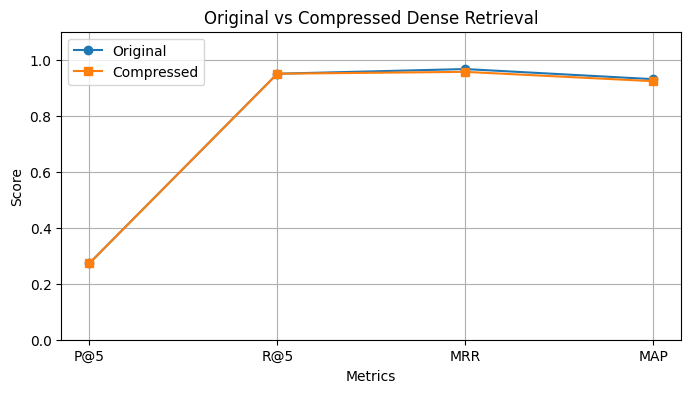

In [14]:
# 시각화
import matplotlib.pyplot as plt

metrics = ['P@5', 'R@5', 'MRR', 'MAP']
original_vals = [original_metrics['P@k'], original_metrics['R@k'], original_metrics['MRR'], original_metrics['MAP']]
compressed_vals = [compressed_metrics['P@k'], compressed_metrics['R@k'], compressed_metrics['MRR'], compressed_metrics['MAP']]

x = range(len(metrics))

plt.figure(figsize=(8, 4))
plt.plot(x, original_vals, marker='o', label='Original')
plt.plot(x, compressed_vals, marker='s', label='Compressed')
plt.xticks(x, metrics)
plt.ylim(0, 1.1)
plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('Original vs Compressed Dense Retrieval')
plt.legend()
plt.grid()
plt.show()